# MNIST CAPTCHA

Αυτό το starter notebook εστιάζει στην επίλυση του προβλήματος MNIST CAPTCHA. Στόχος είναι να σχεδιάσουμε ένα σύστημα που αναγνωρίζει τα ψηφία και τον τελεστή από μία εικόνα τύπου "AB ± CD", ώστε να υπολογίζει το τελικό αποτέλεσμα. Το notebook παρέχει τα ελάχιστα βήματα: εισαγωγές βιβλιοθηκών, λήψη του MNIST dataset και έναν απλό ταξινομητή, ώστε να συνεχίσετε με δικές σας υλοποιήσεις.

**Αυτό το Notebook είναι Read-Only** - οπότε πρέπει να αποθηκεύσετε ένα αντίγραφο στο δικό σας Google Drive.


## Εισαγωγές βιβλιοθηκών

Χρειαζόμαστε την NumPy για διαχείριση πινάκων και την PyTorch για τη δημιουργία και εκπαίδευση νευρωνικών δικτύων. Θα χρησιμοποιήσουμε επίσης το torchvision για να κατεβάσουμε το MNIST dataset μαζί με βασικούς μετασχηματισμούς.


In [1]:
import numpy as np
import torch
from torch import nn
from torchvision import datasets, transforms
from gdown import download
from PIL import Image

## Λήψη των αρχείων

In [2]:
download(id='18IZn5DroVvTkGJEKn5w15RuT61ET9HP0', output='public-clean.png', quiet=False)
download(id='1y3xX9VrM7EtYf1W-3vr-PETE19FnTKHR', output='public-clean.txt', quiet=False)

download(id='1cvDlXQrkLvR_tQBydyms-dt-VSjB7RlG', output='public-noisy.png', quiet=False)
download(id='1V-e76Q8Op3FWFEqb42bvJKllM5LfCdVS', output='public-noisy.txt', quiet=False)

download(id='1JfbYOpBHNrlz-fqgOtLZ8QDidxznug7U', output='private-clean.png', quiet=False)
download(id='1WtozDPV0FjmPthKBBiqBPfd-lhCMxfzk', output='private-noisy.png', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=18IZn5DroVvTkGJEKn5w15RuT61ET9HP0
To: c:\Users\Odysseas\Desktop\Programming\Python\public-clean.png
100%|██████████| 1.92M/1.92M [00:00<00:00, 6.73MB/s]
Downloading...
From: https://drive.google.com/uc?id=1y3xX9VrM7EtYf1W-3vr-PETE19FnTKHR
To: c:\Users\Odysseas\Desktop\Programming\Python\public-clean.txt
100%|██████████| 8.47k/8.47k [00:00<00:00, 6.64MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cvDlXQrkLvR_tQBydyms-dt-VSjB7RlG
To: c:\Users\Odysseas\Desktop\Programming\Python\public-noisy.png
100%|██████████| 2.89M/2.89M [00:00<00:00, 9.32MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V-e76Q8Op3FWFEqb42bvJKllM5LfCdVS
To: c:\Users\Odysseas\Desktop\Programming\Python\public-noisy.txt
100%|██████████| 8.49k/8.49k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1JfbYOpBHNrlz-fqgOtLZ8QDidxznug7U
To: c:\Users\Odysseas\Desktop\Programming\Python\private-clean.png
100%|██████████| 1.92M/1.92M [00:00

'private-noisy.png'

In [3]:
import os
def showImage(tensor):
    transform = transforms.ToPILImage()
    return transform(1-tensor)
def readExamples(file_name):
    transform = transforms.ToTensor()
    image = Image.open(file_name + '.png').convert('L')
    tensor = 1-transform(image)
    X = tensor.reshape(-1,1,28,140)
    if os.path.exists(file_name + '.txt'):
        with open(file_name + '.txt') as f:
            lines = f.readlines()
    else:
        lines = ['']*X.shape[0]
    return X, lines

examples, results = readExamples('public-clean') # or 'public-noisy' or 'private-clean' or 'private-noisy'
print(results[0])
showImage(examples[0])

71



## Λήψη του MNIST dataset

Θα κατεβάσουμε το κλασικό MNIST dataset μέσω του torchvision και θα το μετατρέψουμε σε tensors ώστε να χρησιμοποιηθεί αργότερα στην εκπαίδευση.


In [4]:
from torch.utils.data import random_split

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 60000
Test samples: 10000


In [5]:
image, label = train_dataset[0]
print(label)
showImage(image)


5


# Η Βασική Ιδέα

Για να αυτοματοποιήσουμε την επίλυση των MNIST-CAPTCHA, πρέπει να εκπαιδεύσουμε ένα νευρωνικό που θα μπορεί να αποκωδικοποιήσει το μαθηματικό πρόβλημα από τα ψηφία του MNIST.

Το πρώτο βήμα είναι να εκπαιδεύσουμε ένα νευρωνικό δίκτυο που μπορεί να αναγνωρίσει να ψηφία ένα ένα.

Το επόμενο βήμα είναι να ξεχωρίσουμε τα ψηφία από το Captcha πρόβλημα, να χρησιμοποιήσουμε το εκπαιδευμένο νευρωνικό μας δίκτυο, και μετά να υπολογίσουμε την απάντηση, έχοντας βρεί τους σωστούς αριθμούς.

## Απλό νευρωνικό δίκτυο

Ως ελάχιστη εκκίνηση, ορίζουμε ένα μοντέλο με ένα μόνο γραμμικό επίπεδο (layer) `nn.Linear(28*28, 10)` το οποίο ισοπεδώνει τα pixels και παράγει logits για τις 10 κλάσεις του MNIST.


In [6]:

class SimpleMNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(28 * 28, 10)


    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = SimpleMNISTModel()
print(model)


SimpleMNISTModel(
  (fc): Linear(in_features=784, out_features=10, bias=True)
)


## Υλοποίηση εκπαίδευσης

Στο επόμενο βήμα θα χρειαστεί να γράψετε τη δική σας συνάρτηση εκπαίδευσης ώστε να προσαρμόσετε το μοντέλο στα δεδομένα και να το επεκτείνετε για τη λύση του MNIST CAPTCHA.


In [21]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y):
    device = next(model.parameters()).device  # detect model device

    # make a fine mesh grid of points and label them with model
    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    grid = grid.to(device)  # <<< FIX: move to same device as model

    model.eval()
    with torch.no_grad():
        probs = model(grid)
        Z = probs[:, 0] - probs[:, 1]
        Z = Z.reshape(xx.shape)

    # Move Z back to CPU for plotting
    Z = Z.cpu().numpy()

    plt.contourf(xx, yy, Z, cmap="RdBu", alpha=0.5)

    # Plot original points (must be CPU numpy arrays)
    X = X.cpu().numpy() if isinstance(X, torch.Tensor) else X
    y = y.cpu().numpy() if isinstance(y, torch.Tensor) else y

    positive_indices = np.where(y == 1)[0]
    negative_indices = np.where(y == 0)[0]

    X_positive = X[positive_indices, :]
    X_negative = X[negative_indices, :]

    plt.scatter(X_positive[:,0], X_positive[:,1], marker='^', color='red', label='Positive')
    plt.scatter(X_negative[:,0], X_negative[:,1], marker='o', color='blue', label='Negative')

    plt.title("Decision Region with Data Points")
    plt.show()

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)


# TODO: Γράψτε τον κώδικα εκπαίδευσης του μοντέλου
from torch import optim
import copy

def train(model, train_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.NLLLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
    train_losses = []
    train_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_train_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                total_train_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        epoch_loss = total_train_loss / len(train_loader)
        epoch_accuracy = correct / total
        train_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Training Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Training Accuracy: {best_accuracy:.4f}")

Using device: cuda


In [11]:
# Train the model and plot decision boundary
from torch.utils.data import DataLoader

# 2. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3. Instantiate model + optimizer
model = SimpleMNISTModel()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 4. Train
train(model, train_loader, optimizer, epochs=5)


Epoch 1/5, Training Loss: -41.15060392518176, Training Accuracy: 0.6796
Epoch 2/5, Training Loss: -123.81836517431589, Training Accuracy: 0.6896
Epoch 3/5, Training Loss: -206.68724258520456, Training Accuracy: 0.6975
Epoch 4/5, Training Loss: -289.48751941672776, Training Accuracy: 0.6881
Epoch 5/5, Training Loss: -372.18427222929023, Training Accuracy: 0.6913
Loaded the best model from epoch 3 with Training Accuracy: 0.6975


In [18]:
# Plot decision boundary (for 2D data, not applicable for MNIST but shown as an example)
from sklearn.decomposition import PCA

X = train_dataset.data.reshape(-1, 28*28).float() / 255.0   # shape: (60000, 784)
y = train_dataset.targets                                   # shape: (60000,)

# Reduce to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)


In [19]:
class PCAWrapper(nn.Module):
    def __init__(self, model, pca):
        super().__init__()
        self.model = model
        self.pca = pca

    def forward(self, X2):
        # X2: (N, 2)
        X784 = self.pca.inverse_transform(X2.cpu().numpy())  # back to 784 dims
        X784 = torch.tensor(X784, dtype=torch.float32, device=X2.device)
        return self.model(X784)

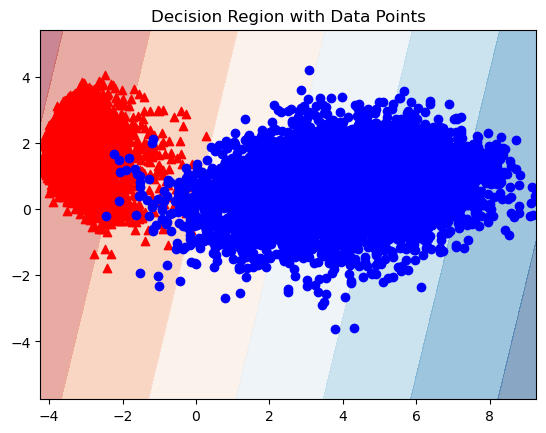

In [22]:
wrapped_model = PCAWrapper(model, pca)
plot_decision_boundary(wrapped_model, X_2d, y)

In [ ]:
# Με βάση το εκπαιδευμένο μοντέλο υλοποιήστε μια συνάρτηση που υπολογίζει την πράξη στο δοσμένο παράδειγμα
def predict(model, x):
    #TODO
    return "37+34=71" #placeholder

## Αποθήκευση Απαντήσεων

In [ ]:
import json
answers = {}
for level in ['public-clean', 'public-noisy', 'private-clean', 'private-noisy']:
    examples, _ = readExamples(level)
    answers[level] = '\n'.join( [predict(model, example) for example in examples] )
with open('answers.json', 'w') as f:
    json.dump(answers, f)

In [ ]:
from google.colab import files
files.download('answers.json')